In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.ticker as ticker
import math
from sklearn import decomposition
import random 

# PEVIDS Project - Victoria Cohort

## Urine Data

samples from Gio, script by Emily

from gio: 

"""
For TIC normalization, so since urine has very big variability in protein amounts patient to patient, or person to person if I injected same amount of it (per volume) I would end up with not comparable intensities. It can be up to 100 times difference just "naturally". So I have to inject same total amount of protein per sample to put them at roughly same level, this is the idea. Regular LFQ normalization style should not work here since the assumption of homeostasis and constant proteome background is only valid for cell culture/tissue proteomics and not valid for body fluids. So in principle urine data should be experimentally normalized by doing this tic normalization. These are independent runs which I did before performing real runs. Here I injected constant amounts (volume) of urine sample per run, 2 micro liter, measured total integrated current (tic) and then based on if it was a big or a small number I adjusted the injected amount for real run according to calibration curve, making sure I have 600 ng per injection constantly across all samples.
"""

In [ ]:
raw_dat = pd.read_csv("../data/report.pg_matrix_pevids_urine_final_no_duplicates.tsv", sep = "\t")
## remove columns im not touching
raw_dat = raw_dat.drop(["Protein.Names", "First.Protein.Description", "N.Sequences", "N.Proteotypic.Sequences", "Genes"], axis = 1)
#raw_dat.head()

In [3]:
res = [x for x in raw_dat.columns if any(y in x for y in ".")]
print("Length of id list with periods: ",len(res))
res.sort()
#
res[:5]
#resdf = pd.DataFrame(res)
#resdf.to_csv("../data/rawdata_columnNames_repeated_20260615.csv")

Length of id list with periods:  1


['Protein.Group']

#### Protein Matrix:

Askk gio: what is the names???

from Gio: "plate_ number_TN_ID"

Emily is inferring:  
 plateNum_platePosition_TNid. so last thing is the most important. 

In [4]:
## read in protein matrix 
data_dic = pd.read_excel("../data/2026_04_23_PEVIDS_München_Urin_mit_TNID_und_MZP_BS.xlsx")
#data_dic.head()

In [5]:
raw_dat.shape

(3310, 1156)

In [ ]:
data_dic.head()

### Quality control

In [ ]:
## set index 
raw_dat.set_index('Protein.Group', inplace=True)
#raw_dat.head()

In [8]:
## extract sample names and plate info
samp_list = raw_dat.columns.to_list()#.str.lstrip("plate_") # drop(['Protein.Ids', 'Genes', 'First.Protein.Description'],
## remove excess strings
samp_list = [x.replace('plate_', '') for x in samp_list ] 
## replace weird name 'D:\\Gio\\Pevids_fragpipe\\20260325_Urinomics_main_2_8_H11_uncalibrated.mzML',
samp_list = ["2_8_H11_uncalibrated" if x == f'D:\\Gio\\Pevids_fragpipe\\20260325_Urinomics_main_2_8_H11_uncalibrated.mzML' else x for x in samp_list]
## confirm it worked
#samp_list[1000:] ## good 
raw_dat.columns = samp_list


In [9]:
## list to df with values
samp_map = pd.DataFrame(samp_list)
samp_map.columns = ["og_name"] #"experimental_batch", "plate_number", "TN_ID"]
samp_map['exp_batch'] = samp_map['og_name'].str.split("_", expand = True)[0]
samp_map['TN_ID'] = samp_map['og_name'].str.split("_") ## always last
samp_map.TN_ID = samp_map.TN_ID.str[-1] ## for some reason only works as intermediate step
## add plate num
samp_map.loc[samp_map['exp_batch'] == 'bridge', 'plate_num'] = '1_1'
samp_map.loc[samp_map['exp_batch'] != 'bridge', 'plate_num'] = samp_map.apply(lambda x: x['exp_batch'] + "_" + x['og_name'].split("_")[1], axis = 1)

#samp_map['plate_num'] = np.where(samp_map['exp_batch'] == "bridge", "100", samp_map['plate_num'])
#samp_map['plate_num'] = samp_map['og_name'].str.split("_", expand = True)[1]


samp_map.head()

,og_name,exp_batch,TN_ID,plate_num
0,2_6_1145_1,2,1,2_6
1,bridge_7017_1,bridge,1,1_1
2,3_2_2048_2,3,2,3_2
3,2_7_2009_1,2,1,2_7
4,2_1_6025_1,2,1,2_1


In [10]:
## removing weird sample for now
samp_map = samp_map[~samp_map['plate_num'].str.contains("Gio") ]
# D:\Gio\Pevids_fragpipe\20260325_Urinomics_main_2_8_H11
raw_dat = raw_dat.drop(r'D:\Gio\Pevids_fragpipe\20260325_Urinomics_main_2_8_H11', axis = 1)

from here, I'm assuming I can ignore the decimal and things that come after it 

### Remove Contaminants

[This source from the Hao group](https://github.com/HaoGroup-ProtContLib/Protein-Contaminant-Libraries-for-DDA-and-DIA-Proteomics) seems quite reliable with diff sample type contaminants  


In [11]:
## remove contaminants 
## this source from the hao group seems quite reliable with diff sample type contaminants
# https://github.com/HaoGroup-ProtContLib/Protein-Contaminant-Libraries-for-DDA-and-DIA-Proteomics 
## be sure to cite 
contam_dat = pd.read_csv("~/PEVIDS/PEVIDS_plasma/dat/HaoGroup_ContaminantUniversalProteins.csv", skiprows = 1) ## in the same utils/ folder 
contam_dat.drop(['Status'], axis = 1, inplace = True) 
contam_ids = list(contam_dat['Uniprot ID'])


In [12]:

## apply to our data
measured_contaminants = raw_dat.loc[raw_dat.index.isin(contam_ids)]
## remove columns (samples) with no measured NA
measured_contaminants.dropna(axis = 1, how = 'all', inplace = True)
measured_contaminants =  contam_dat.merge(measured_contaminants, how = 'right', right_on = 'Protein.Group', left_on = 'Uniprot ID')
## write this to a seperate file in the results so ppl can ID on their own if they want to. 
contam_file_name = os.path.join("../results/contaminants_ided_with_intensities_source.csv") 
measured_contaminants.to_csv(contam_file_name)
## give some info to log file
count_of_contams = len(measured_contaminants['Uniprot ID'].unique())
print(f"Identified {count_of_contams} contaminants in the data;\nWriting IDed contaminants and intensities to files . . . ")

## now remove these contaminants from our data
dat_filt = raw_dat[~raw_dat.index.isin(contam_ids)]
og_rows = raw_dat.shape[0]
new_rows = dat_filt.shape[0]
ids_removed = og_rows - new_rows
print(f"Applying contaminant filtering . . . ")#\n\tactual number of rows (IDs) removed is {ids_removed} (compared to the number of contaminants we IDs, {count_of_contams}; these numbers should be equal)")
if ids_removed == count_of_contams:
    print("\tExpected number of contaminants removed!")
else:
    print(f"\tSomething weird happened; we identified {count_of_contams} contaminants, but removed {ids_removed} rows. Please manually inspect.")

dat_filt.head()

Identified 71 contaminants in the data;
Writing IDed contaminants and intensities to files . . . 
Applying contaminant filtering . . . 
	Expected number of contaminants removed!


/tmp/ipykernel_125/633894992.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  measured_contaminants.dropna(axis = 1, how = 'all', inplace = True)


,2_6_1145_1,bridge_7017_1,3_2_2048_2,2_7_2009_1,2_1_6025_1,2_7_2024_1,3_1_1350_1,bridge_1024_1,3_3_2053_1,3_2_1349_3,...,2_8_7031_2,3_2_1327_3,2_1_5025_2,3_3_1299_1,2_5_1262_1,2_8_1068_1,2_2_6007_3,3_1_5087_3,3_1_1285_2,2_6_5071_3
Protein.Group,,,,,,,,,,,,,,,,,,,,,
A0A024RBG1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A0A075B6H7,124000000.0,66300000.0,61000000.0,85100000.0,277000000.0,79800000.0,47300000.0,190000000.0,163000000.0,170000000.0,...,39000000.0,77400000.0,124000000.0,112000000.0,484000000.0,211000000.0,368000000.0,83500000.0,247000000.0,85900000.0
A0A075B6H9,18600000.0,7050000.0,3690000.0,3950000.0,46700000.0,7890000.0,11700000.0,18800000.0,6790000.0,27100000.0,...,43300000.0,12600000.0,14100000.0,8120000.0,13900000.0,33500000.0,57500000.0,22900000.0,18500000.0,19000000.0
A0A075B6I0,25300000.0,3660000.0,2060000.0,NaN,11800000.0,29200000.0,4040000.0,8410000.0,3600000.0,12700000.0,...,5290000.0,12400000.0,13600000.0,49000000.0,14900000.0,13800000.0,33800000.0,8900000.0,13600000.0,48800000.0
A0A075B6I1,2080000.0,NaN,1220000.0,NaN,NaN,NaN,1370000.0,2330000.0,339802.0,2100000.0,...,NaN,NaN,3270000.0,NaN,1450000.0,NaN,NaN,NaN,NaN,989486.0


In [14]:
dat_filt.shape

(3239, 1154)

## Before Transformation
### Plot Plate-Wise median Intensity 

I do not have MS consec number from the urine data, so I can't make the same exact plot. 

In [15]:
# first calculate median intensity for each sample column
medians = dat_filt.median(axis=0)
median_df = medians.reset_index()
median_df.columns = ['og_name', 'median_intensity']

plot_df = median_df.merge(
    samp_map[['og_name', 'exp_batch', 'plate_num', 'TN_ID']],
    on='og_name',
    how='left'
)


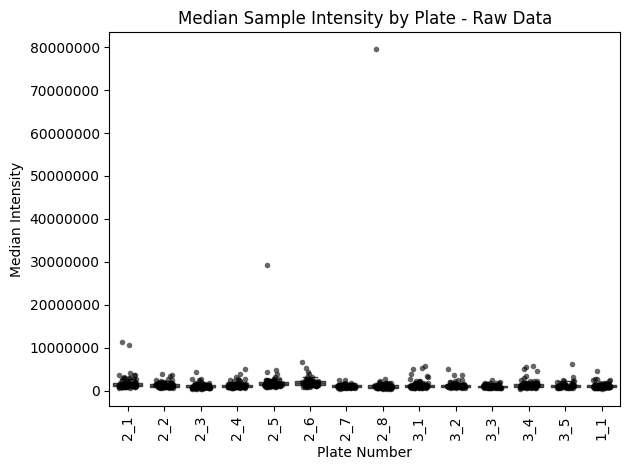

In [16]:
plate_order = (
    plot_df[['exp_batch', 'plate_num']]
    .drop_duplicates()
    .sort_values(['exp_batch', 'plate_num'])
    ['plate_num']
    .tolist()
)
plot_df['batch_plate'] = (
    plot_df['exp_batch'].astype(str) +
    '_P' +
    plot_df['plate_num'].astype(str)
)

# Plot
#plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_df,
    x='plate_num',
    y='median_intensity',
    order=plate_order,
    showfliers=False
)

sns.stripplot(
    data=plot_df,
    x='plate_num',
    y='median_intensity',
    order=plate_order,
    color='black',
    alpha=0.6,
    jitter=0.25,
    size=4
)

plt.xlabel("Plate Number")
plt.ylabel("Median Intensity")
plt.title("Median Sample Intensity by Plate - Raw Data")
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('../results/01_qc_median_intensity_raw_urine.png', dpi = 300)
plt.show()


#### Investigate Batch Effect

According to Gio, TIC normalization is already applied as it is applied experimentally. 

I will proceed with log2 transofrmation then PCA to investigate batch effect

In [ ]:
## log2 transf for whole df, no median centering or regard for plate

dat_log2 = np.log2(dat_filt)
#dat_log2.head()

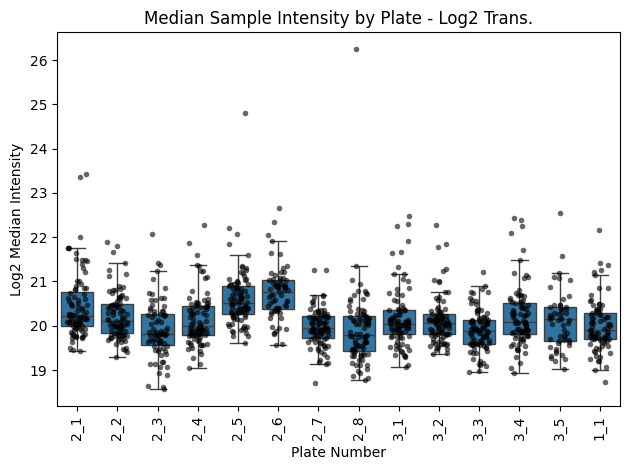

In [18]:
## repeat of the above plot 
# first calculate median intensity for each sample column
medians = dat_log2.median(axis=0)
median_df = medians.reset_index()
median_df.columns = ['og_name', 'median_intensity']
## remake plot df 
plot_df = median_df.merge(
    samp_map[['og_name', 'exp_batch', 'plate_num', 'TN_ID']],
    on='og_name',
    how='left'
)

plate_order = (plot_df[['exp_batch', 'plate_num']]
    .drop_duplicates()
    .sort_values(['exp_batch', 'plate_num'])['plate_num']
    .tolist()
)
plot_df['batch_plate'] = (
    plot_df['exp_batch'].astype(str) +
    '_P' +
    plot_df['plate_num'].astype(str)
)

# Plot
#plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_df,
    x='plate_num',
    y='median_intensity',
    order=plate_order,
    showfliers=False
)

sns.stripplot(
    data=plot_df,
    x='plate_num',
    y='median_intensity',
    order=plate_order,
    color='black',
    alpha=0.6,
    jitter=0.25,
    size=4
)

plt.xlabel("Plate Number")
plt.ylabel("Log2 Median Intensity")
plt.title("Median Sample Intensity by Plate - Log2 Trans.")
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('../results/01_qc_median_intensity_log2_urine.png', dpi = 300)
plt.show()


In [19]:

samp_map[samp_map['plate_num'].str.contains("Gio")]

#samp_map.loc[:,'plate_num'==r"D:\Gio\Pevids_fragpipe\20260325"]

,og_name,exp_batch,TN_ID,plate_num


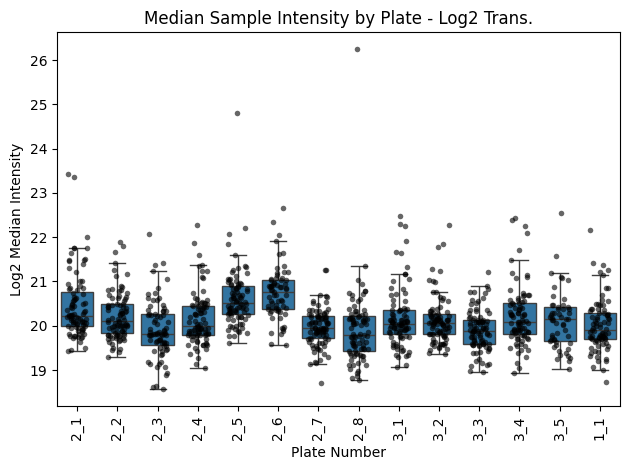

In [20]:
## repeat of the above plot 
# first calculate median intensity for each sample column
medians = dat_log2.median(axis=0)
median_df = medians.reset_index()
median_df.columns = ['og_name', 'median_intensity']
## remake plot df 
plot_df = median_df.merge(
    samp_map[['og_name', 'exp_batch', 'plate_num', 'TN_ID']],
    on='og_name',
    how='left'
)

plate_order = (plot_df[['exp_batch', 'plate_num']]
    .drop_duplicates()
    .sort_values(['exp_batch', 'plate_num'])['plate_num']
    .tolist()
)
plot_df['batch_plate'] = (
    plot_df['exp_batch'].astype(str) +
    '_P' +
    plot_df['plate_num'].astype(str)
)

# Plot
#plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_df,
    x='plate_num',
    y='median_intensity',
    order=plate_order,
    showfliers=False
)

sns.stripplot(
    data=plot_df,
    x='plate_num',
    y='median_intensity',
    order=plate_order,
    color='black',
    alpha=0.6,
    jitter=0.25,
    size=4
)

plt.xlabel("Plate Number")
plt.ylabel("Log2 Median Intensity")
plt.title("Median Sample Intensity by Plate - Log2 Trans.")
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('../results/01_qc_median_intensity_log2_urine.png', dpi = 300)
plt.show()


### Global Median Centering

There appears to be some effect of plate order on median intensity, though no obvious batch effect by pca. so we will add a global median centering on the protein group to accress this 

In [21]:
dat_log2.head()
sample_medians = dat_log2.median(axis = 0)
## want mean per sample according to Matthew's previous message
global_median = sample_medians.median()
log2_centered = dat_log2.sub(sample_medians, axis = 1).add(global_median)

In [22]:
## examine median centering 
(sample_medians - global_median).describe()

count    1154.000000
mean        0.092425
std         0.674176
min        -1.517212
25%        -0.317163
50%         0.000000
75%         0.388939
max         6.155484
dtype: float64

<Axes: >

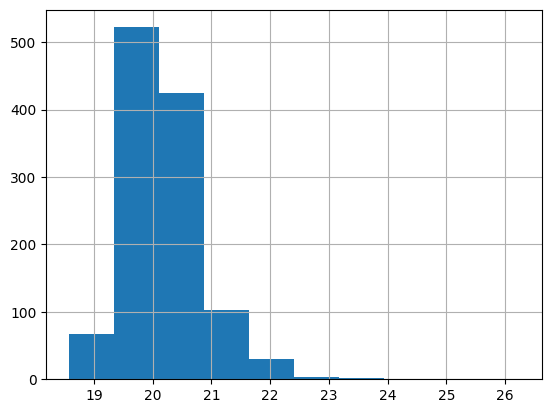

In [23]:
sample_medians.hist()

### Repeat Boxplots After Median Centering on Log2 Matrix

In [25]:
## pca set up 
## get palette
print("there are a total of ", len(samp_map['plate_num'].unique()), " unique plates.")
palette_len = len(samp_map['plate_num'].unique())
custom_palette = sns.color_palette("tab20b", palette_len)

lowest_obs_intensity = log2_centered.min().min()

there are a total of  14  unique plates.


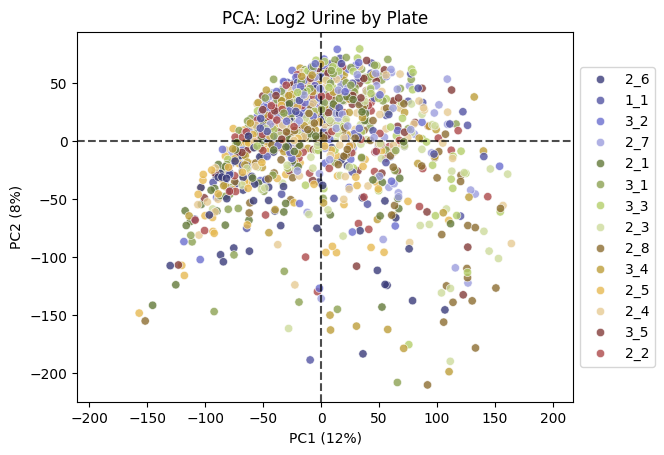

In [26]:
## FOR PCA ONLY - do something to NAs
df_no_nas = log2_centered.T.fillna(lowest_obs_intensity, inplace = False)
## pca
pca = decomposition.PCA(n_components=2)
pca.fit(df_no_nas)
pc = pca.transform(df_no_nas)

pc_df = pd.DataFrame(
        data=pc,
        columns = ['pc1', 'pc2'],
        index=plot_df['plate_num']    
)

## add plot elements
ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = custom_palette)
plt.axhline(y=0, color = "black", ls = "--", alpha = 0.7) 
plt.axvline(x=0, color = "black", ls = "--", alpha = 0.7) 
 #pc_df.apply(lambda x: ax.text(x['PC1']+0.05, x['PC2'], x.name), axis=1);
plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)')
plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)')
ax.set(title = "PCA: Log2 Urine by Plate")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.axis('equal')
ax.figure.savefig("../results/01_qc_pca_log2_median_centered_platenum.png", bbox_inches='tight', dpi = 300) 


In [27]:
samp_map['plate_num'].value_counts()

plate_num
2_7    88
3_2    88
2_1    88
3_1    88
2_5    88
3_3    88
2_2    88
3_4    86
2_4    86
2_8    86
1_1    81
2_3    78
2_6    67
3_5    54
Name: count, dtype: int64

/tmp/ipykernel_125/2110754167.py:13: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = sns.color_palette("Set2"))


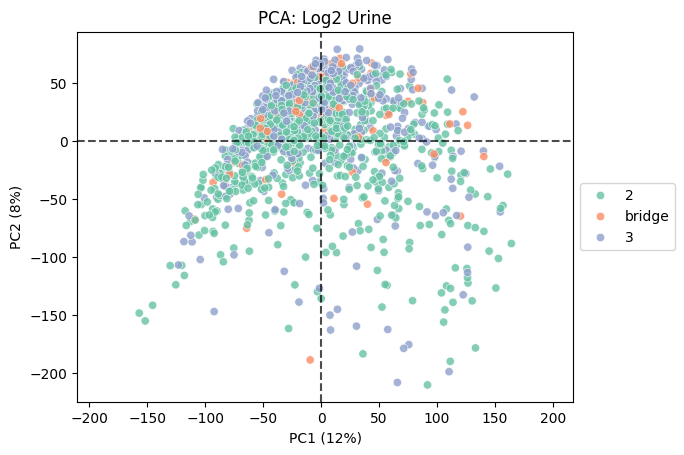

In [28]:
## pca
pca = decomposition.PCA(n_components=2)
pca.fit(df_no_nas)
pc = pca.transform(df_no_nas)

pc_df = pd.DataFrame(
        data=pc,
        columns = ['pc1', 'pc2'],
        index=samp_map['exp_batch']    
)

## add plot elements
ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue = pc_df.index, alpha = 0.8, palette = sns.color_palette("Set2"))
plt.axhline(y=0, color = "black", ls = "--", alpha = 0.7) 
plt.axvline(x=0, color = "black", ls = "--", alpha = 0.7) 
 #pc_df.apply(lambda x: ax.text(x['PC1']+0.05, x['PC2'], x.name), axis=1);
plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)')
plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)')
ax.set(title = "PCA: Log2 Urine")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.axis('equal')
ax.figure.savefig("../results/01_qc_pca_log2_median_centered_expbatch.png", bbox_inches='tight', dpi = 300) 


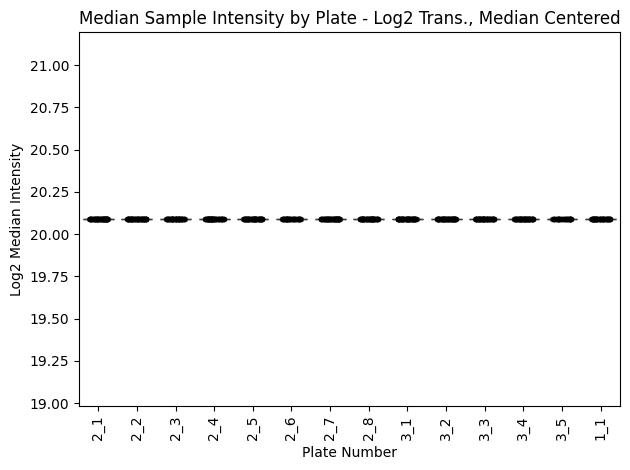

this looks absurb but is expected behavior! median centering should give all samples across all plates the same median intensity value


In [29]:
## repeat of the above plot 
# first calculate median intensity for each sample column
medians = log2_centered.median(axis=0)
median_df = medians.reset_index()
median_df.columns = ['og_name', 'median_intensity']
## remake plot df 
plot_df = median_df.merge(
    samp_map[['og_name', 'exp_batch', 'plate_num', 'TN_ID']],
    on='og_name',
    how='left'
)

plate_order = (plot_df[['exp_batch', 'plate_num']]
    .drop_duplicates()
    .sort_values(['exp_batch', 'plate_num'])['plate_num']
    .tolist()
)
plot_df['batch_plate'] = (
    plot_df['exp_batch'].astype(str) +
    '_P' +
    plot_df['plate_num'].astype(str)
)

# Plot
#plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_df,
    x='plate_num',
    y='median_intensity',
    order=plate_order,
    showfliers=False
)

sns.stripplot(
    data=plot_df,
    x='plate_num',
    y='median_intensity',
    order=plate_order,
    color='black',
    alpha=0.6,
    jitter=0.25,
    size=4
)

plt.xlabel("Plate Number")
plt.ylabel("Log2 Median Intensity")
plt.title("Median Sample Intensity by Plate - Log2 Trans., Median Centered")
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('../results/01_qc_median_intensity_log2_median_centered_urine.png', dpi = 300)
plt.show()
print("this looks absurb but is expected behavior! median centering should give all samples across all plates the same median intensity value")